# Preparation

In [1]:
from pprint import pprint
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from matplotlib import pyplot as plt
import os
from datasets.data_processing import preprocess_df
from datasets.telco import load_telco_df
from gragod import start_research
from gragod.metrics.calculator import MetricsCalculator, get_metrics
from gragod.metrics.visualization import plot_single_score_histogram
from gragod.predictions.prediction import get_threshold_system
from gragod.predictions.spot import SPOT
from gragod.training import load_params
from gragod.types import Datasets, Models, ParamFileTypes
from models.predict import predict

Working on /Users/gonza/facultad/tesis/GraGOD
Loaded .env file: False


In [2]:
dataset = Datasets.TELCO.value


def load_dataset_predictions(model_name: str, dataset_name: str, split: str = "test"):
    data_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_data.pt"
    labels_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_labels.pt"
    output_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_output.pt"
    predictions_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_predictions.pt"
    scores_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_scores.pt"
    threshold_path = f"../results/test_{dataset_name}/{model_name}/version_0/predictions/{split}_{model_name}_{dataset_name}_thresholds.pt"

    data = torch.load(data_path)
    labels = torch.load(labels_path)
    output = torch.load(output_path)
    predictions = torch.load(predictions_path)
    scores = torch.load(scores_path)
    threshold = torch.load(threshold_path)

    labels_single = (torch.sum(labels, dim=1) > 0).int()
    predictions_single = (torch.sum(predictions, dim=1) > 0).int()
    scores_single = torch.mean(scores, dim=1)[0]

    return (
        data,
        labels,
        output,
        predictions,
        scores,
        labels_single,
        scores_single,
        predictions_single,
        threshold,
    )


def load_graph_model_predictions(
    model_name: str, dataset_name: str, split: str = "test"
):
    data_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_data.pt"
    labels_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_labels.pt"
    output_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_output.pt"
    predictions_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_predictions.pt"
    scores_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_scores.pt"
    threshold_path = f"../results/{model_name}_{dataset_name}_graph/{split}_{model_name}_{dataset_name}_thresholds.pt"

    data = torch.load(data_path)
    labels = torch.load(labels_path)
    output = torch.load(output_path)
    predictions = torch.load(predictions_path)
    scores = torch.load(scores_path)
    threshold = torch.load(threshold_path)

    labels_single = (torch.sum(labels, dim=1) > 0).int()
    predictions_single = (torch.sum(predictions, dim=1) > 0).int()
    scores_single = torch.mean(scores, dim=1)[0]

    return (
        data,
        labels,
        output,
        predictions,
        scores,
        labels_single,
        scores_single,
        predictions_single,
        threshold,
    )

(
    data_gru_train,
    labels_gru_train,
    output_gru_train,
    predictions_gru_train,
    scores_gru_train,
    labels_gru_single_train,
    scores_gru_single_train,
    predictions_gru_single_train,
    threshold_gru_train,
) = load_dataset_predictions("gru", "telco", split="train")
(
    data_gru_val,
    labels_gru_val,
    output_gru_val,
    predictions_gru_val,
    scores_gru_val,
    labels_gru_single_val,
    scores_gru_single_val,
    predictions_gru_single_val,
    threshold_gru_val,
) = load_dataset_predictions("gru", "telco", split="val")

(
    data_mtad_gat_val,
    labels_mtad_gat_val,
    output_mtad_gat_val,
    predictions_mtad_gat_val,
    scores_mtad_gat_val,
    labels_mtad_gat_single_val,
    scores_mtad_gat_single_val,
    predictions_mtad_gat_single_val,
    threshold_mtad_gat_val,
) = load_dataset_predictions("mtad_gat", "telco", split="val")
(
    data_gru_test,
    labels_gru_test,
    output_gru_test,
    predictions_gru_test,
    scores_gru_test,
    labels_gru_single_test,
    scores_gru_single_test,
    predictions_gru_single_test,
    threshold_gru_test,
) = load_dataset_predictions("gru", "telco", split="test")
(
    data_mtad_gat_test,
    labels_mtad_gat_test,
    output_mtad_gat_test,
    predictions_mtad_gat_test,
    scores_mtad_gat_test,
    labels_mtad_gat_single_test,
    scores_mtad_gat_single_test,
    predictions_mtad_gat_single_test,
    threshold_mtad_gat_test,
) = load_dataset_predictions("mtad_gat", "telco", split="test")
(
    data_gdn_val,
    labels_gdn_val,
    output_gdn_val,
    predictions_gdn_val,
    scores_gdn_val,
    labels_gdn_single_val,
    scores_gdn_single_val,
    predictions_gdn_single_val,
    threshold_gdn_val,
) = load_dataset_predictions("gdn", "telco", split="val")
(
    data_gdn_test,
    labels_gdn_test,
    output_gdn_test,
    predictions_gdn_test,
    scores_gdn_test,
    labels_gdn_single_test,
    scores_gdn_single_test,
    predictions_gdn_single_test,
    threshold_gdn_test,
) = load_dataset_predictions("gdn", "telco", split="test")
(
    data_gcn_val,
    labels_gcn_val,
    output_gcn_val,
    predictions_gcn_val,
    scores_gcn_val,
    labels_gcn_single_val,
    scores_gcn_single_val,
    predictions_gcn_single_val,
    threshold_gcn_val,
) = load_dataset_predictions("gcn", "telco", split="val")
(
    data_gcn_test,
    labels_gcn_test,
    output_gcn_test,
    predictions_gcn_test,
    scores_gcn_test,
    labels_gcn_single_test,
    scores_gcn_single_test,
    predictions_gcn_single_test,
    threshold_gcn_test,
) = load_dataset_predictions("gcn", "telco", split="test")

# Plotting functions

In [3]:
from PIL import Image
import math
def generate_forecast_and_series_fig(y_pred, y_true, labels, model_name, dataset_name, fig_name, plot_legend=False, title=None):
    """
    Generate a figure with the forecast and the series, without plotting the figure
    """
    if not os.path.exists("figures"):
        os.makedirs("figures")
    if not os.path.exists(os.path.join("figures", dataset_name)):
        os.makedirs(os.path.join("figures", dataset_name))
    if not os.path.exists(os.path.join("buffer")):
        os.makedirs(os.path.join("buffer"))
    if not os.path.exists(os.path.join("buffer", dataset_name)):
        os.makedirs(os.path.join("buffer", dataset_name))
    

    fig = plt.figure(figsize=(14, 10))
    plt.plot(y_pred, label="Forecast", color="green", linewidth=3)
    plt.plot(y_true, label="Data", color="blue", linewidth=3)

    # Add background color based on labels using fill_between
    ax = plt.gca()
    x = np.arange(len(labels))

    xticks = [0, len(x), len(x) // 2]
    plt.xticks(xticks, [f"{tick}" for tick in xticks], fontsize=50)
    # yticks = np.linspace(min(plt.yticks()[0]), max(plt.yticks()[0]), 5)
    # plt.yticks(yticks, [f"{tick:.1f}" for tick in yticks], fontsize=20)
    min_y = math.floor(min(torch.min(y_pred), torch.min(y_true)) * 10) / 10
    max_y = math.ceil(max(torch.max(y_pred), torch.max(y_true)) * 10) / 10
    plt.yticks([min_y, max_y], [f"{min_y:.1f}", f"{max_y:.1f}"], fontsize=50)
    if plot_legend:
        plt.legend(fontsize=50, title_fontsize=50)
    # plt.grid(True)
    idx_ranges = []
    anomaly_indices = np.where(labels == 1)[0]
    for k, g in itertools.groupby(
        enumerate(anomaly_indices), lambda x: x[0] - x[1]
    ):
        group = list(map(lambda x: x[1], g))
        idx_ranges.append((group[0], group[-1]))

    for start, end in idx_ranges:
        plt.axvspan(start , end , color="red", alpha=0.2)
    if title:
        plt.title(title, fontsize=50)
    # save fig
    plt.savefig(os.path.join("buffer", dataset_name, fig_name))
    plt.savefig(os.path.join("figures", dataset_name, fig_name.replace(".png", ".pdf")))
    plt.close(fig)
    # return 


def generate_grid(figs_paths: list[str], dataset_name: str, cols: int, file_name: str):
    # Load all images as PIL Images
    images = [Image.open(os.path.join("buffer", dataset_name, path)) for path in figs_paths]
    
    # Calculate grid dimensions
    rows = (len(images) + cols - 1) // cols
    width, height = images[0].size  # Assume all images are same size
    
    # Create combined image
    combined = Image.new('RGB', (cols * width, rows * height))
    
    # Paste images into grid
    for i, img in enumerate(images):
        row = i // cols
        col = i % cols
        combined.paste(img, (col * width, row * height))
    
    # save combined image
    combined.save(os.path.join("buffer", dataset_name, file_name))
    combined.save(os.path.join("figures", dataset_name, file_name.replace(".png", ".pdf")))
    return combined




# Benchmark analysis


## Random snapshot

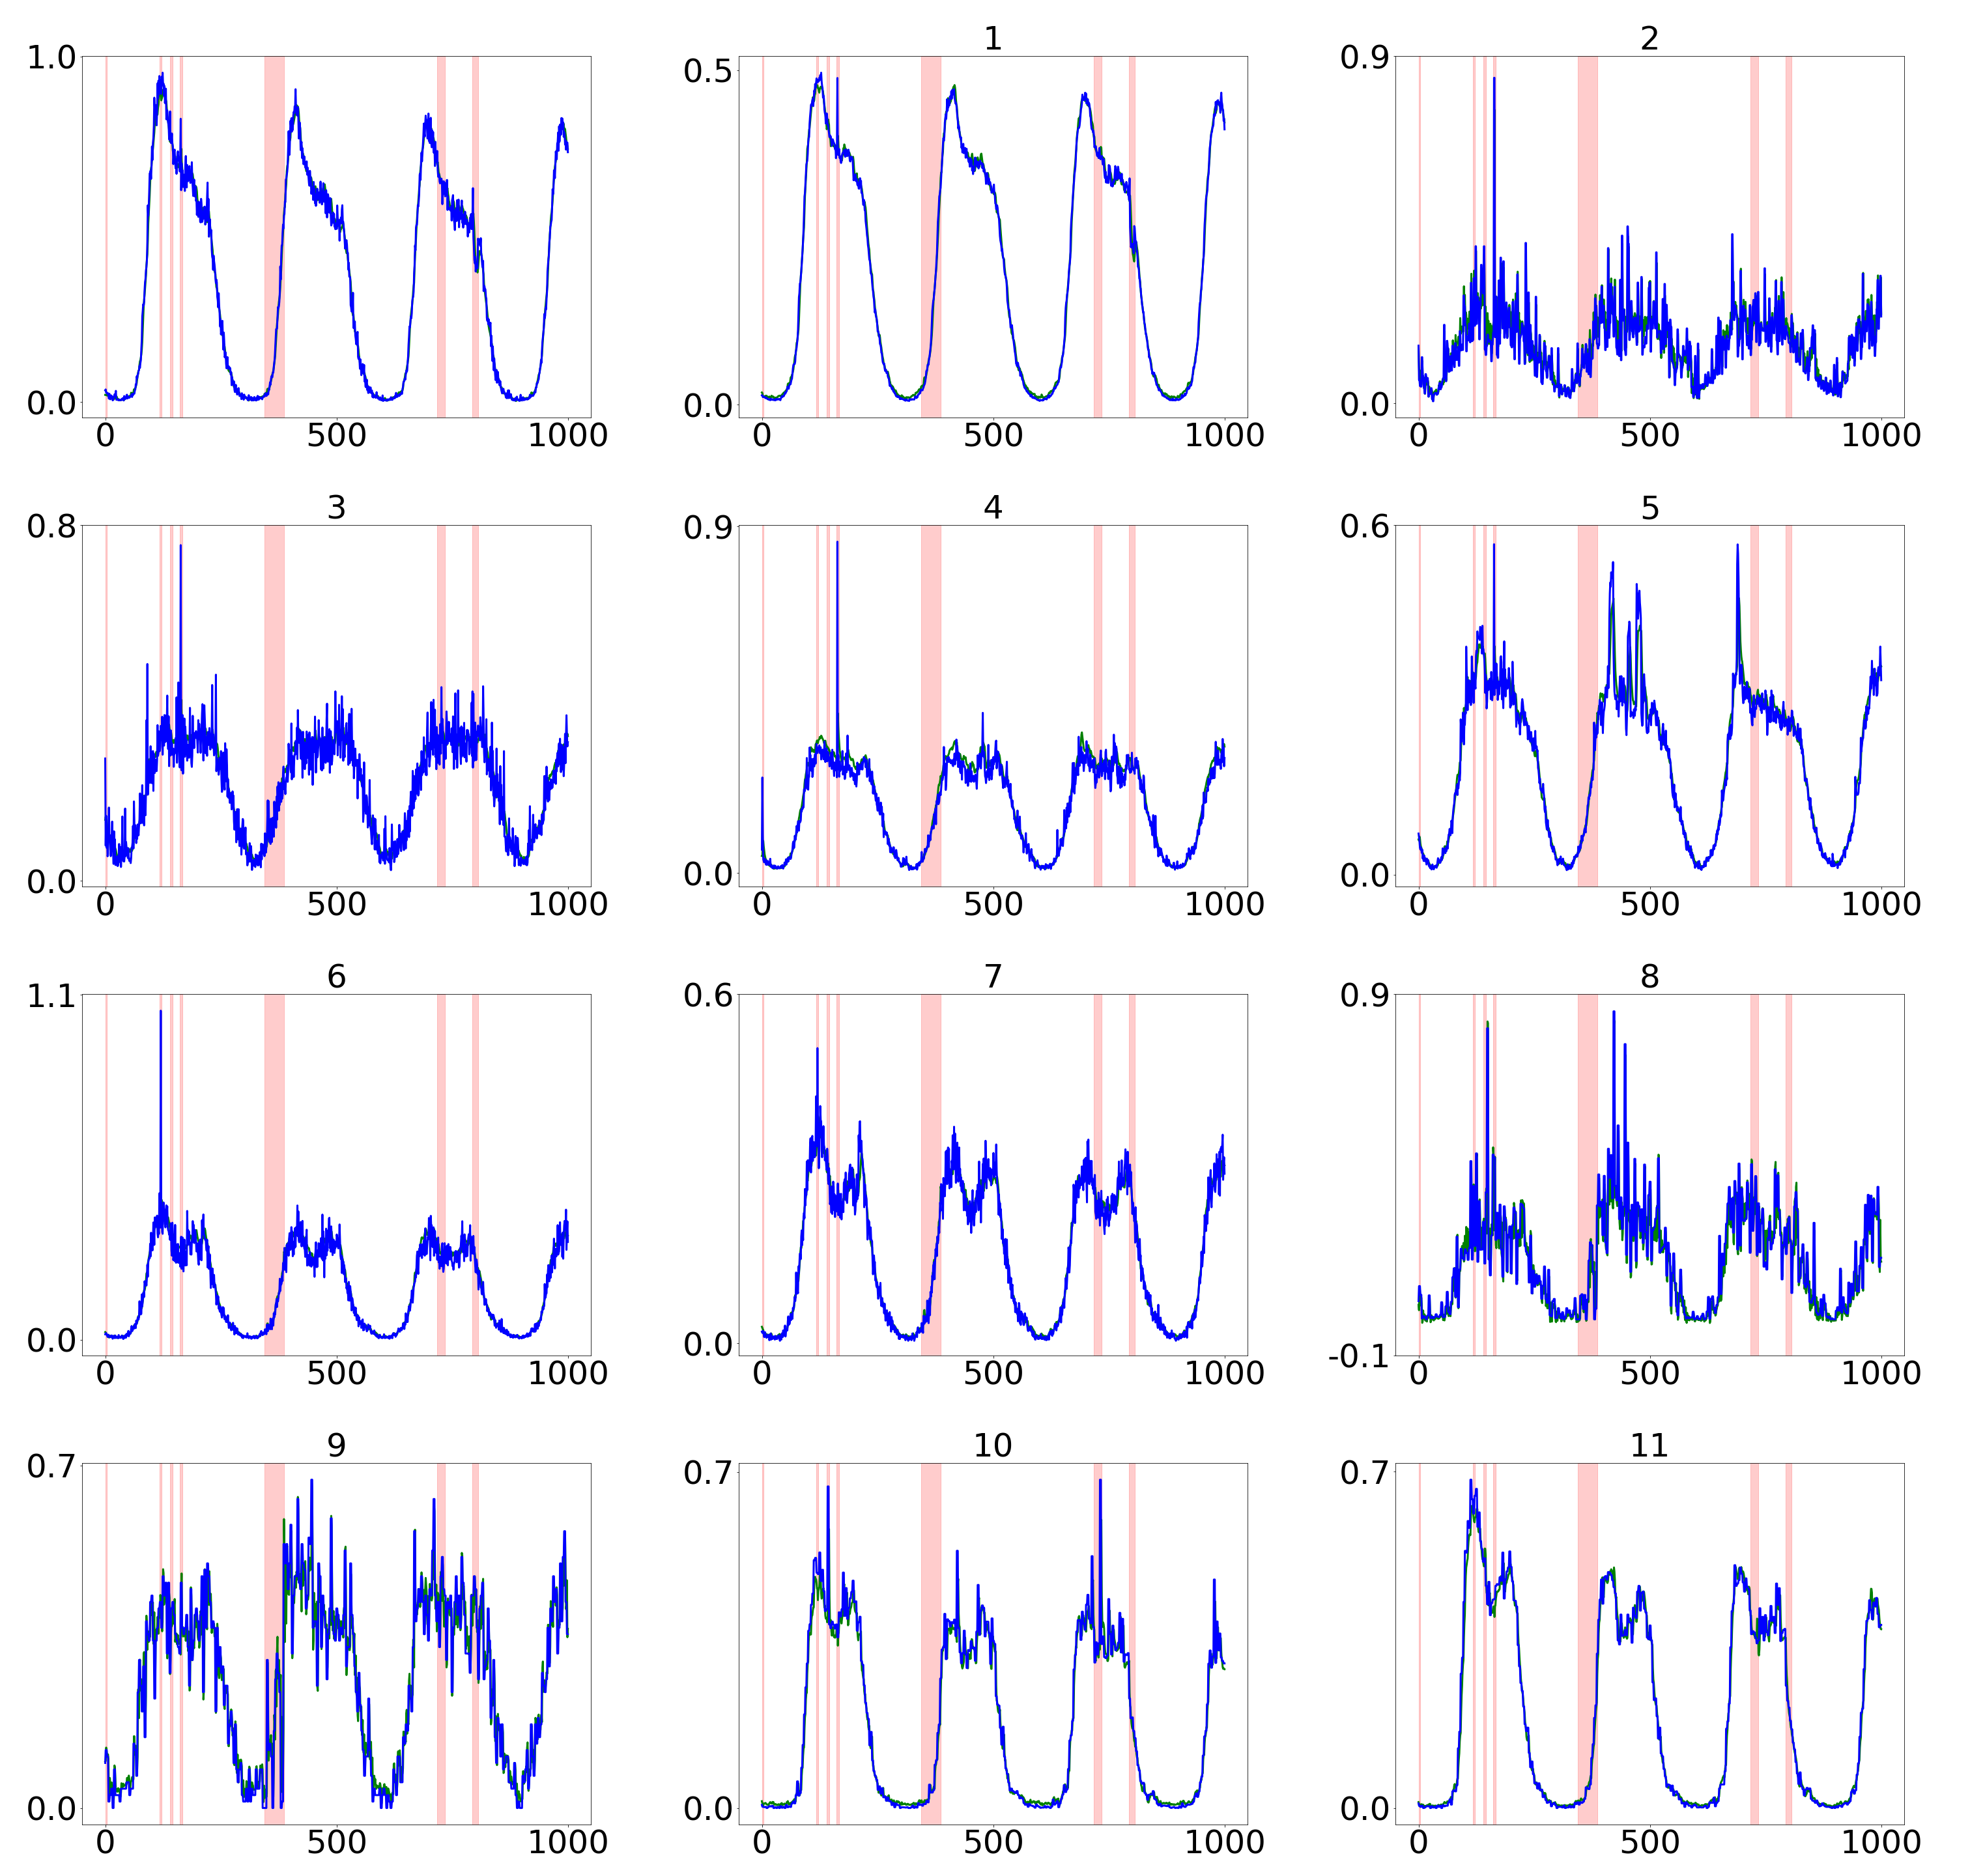

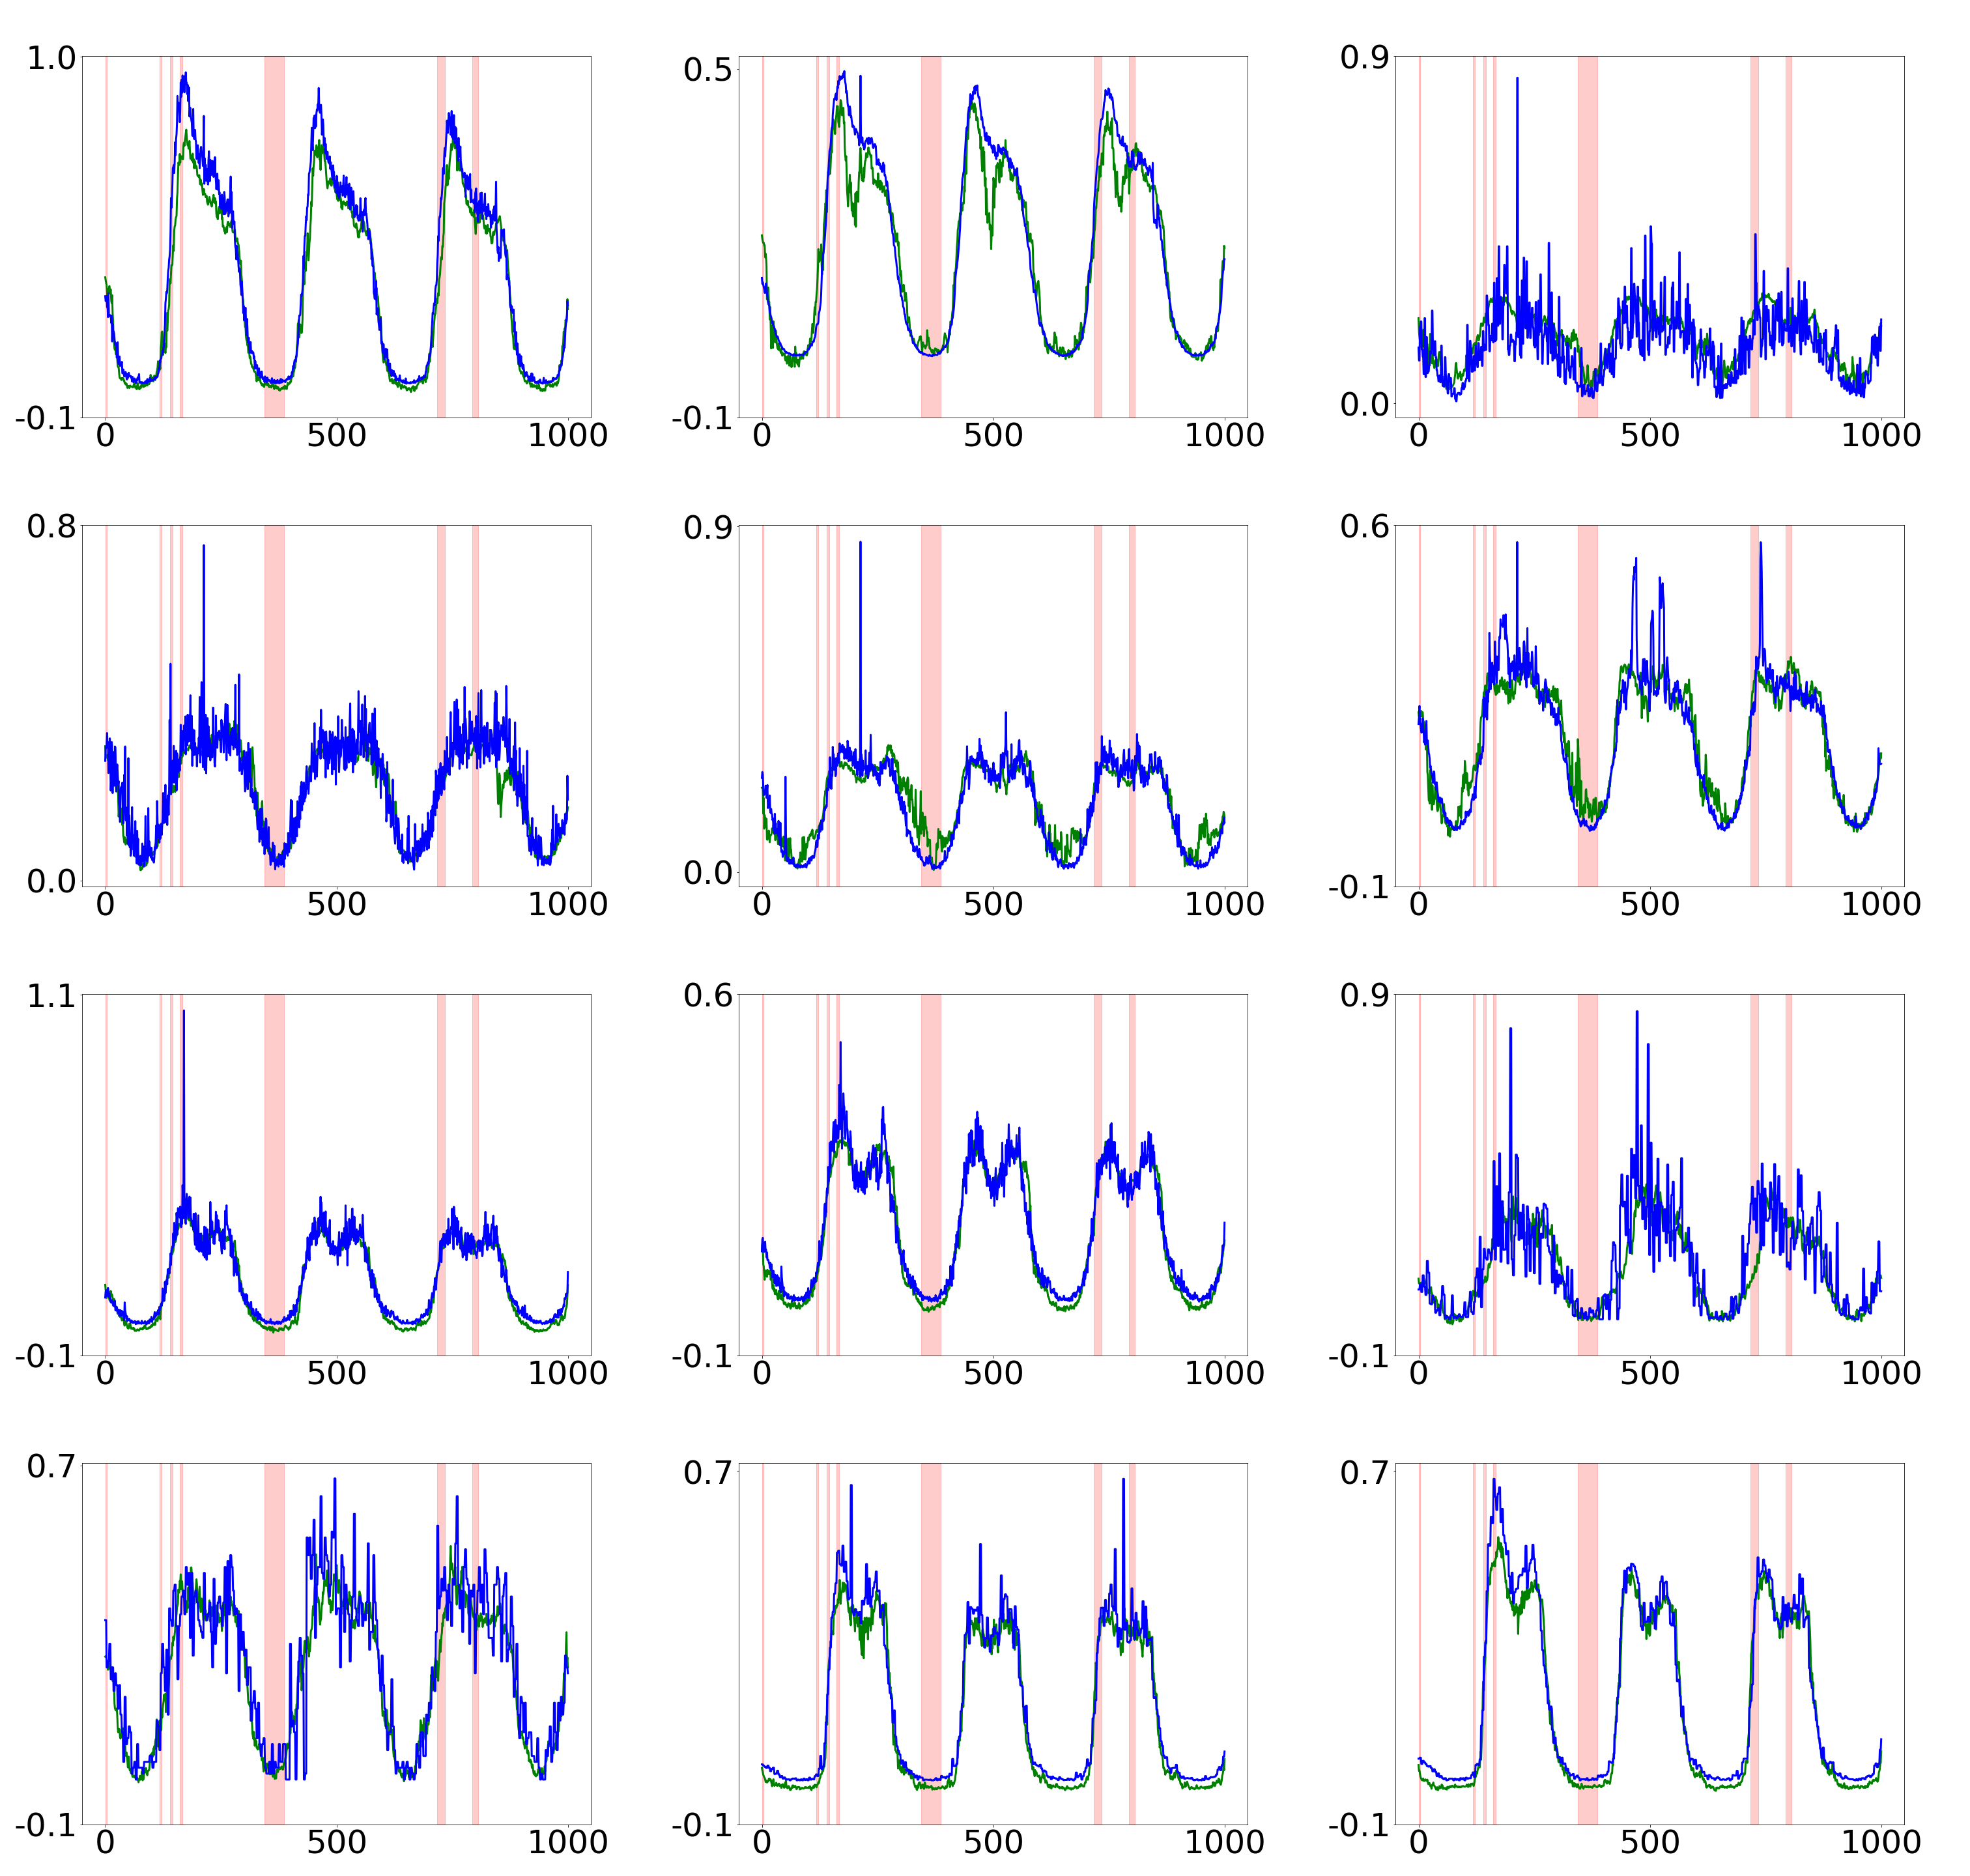

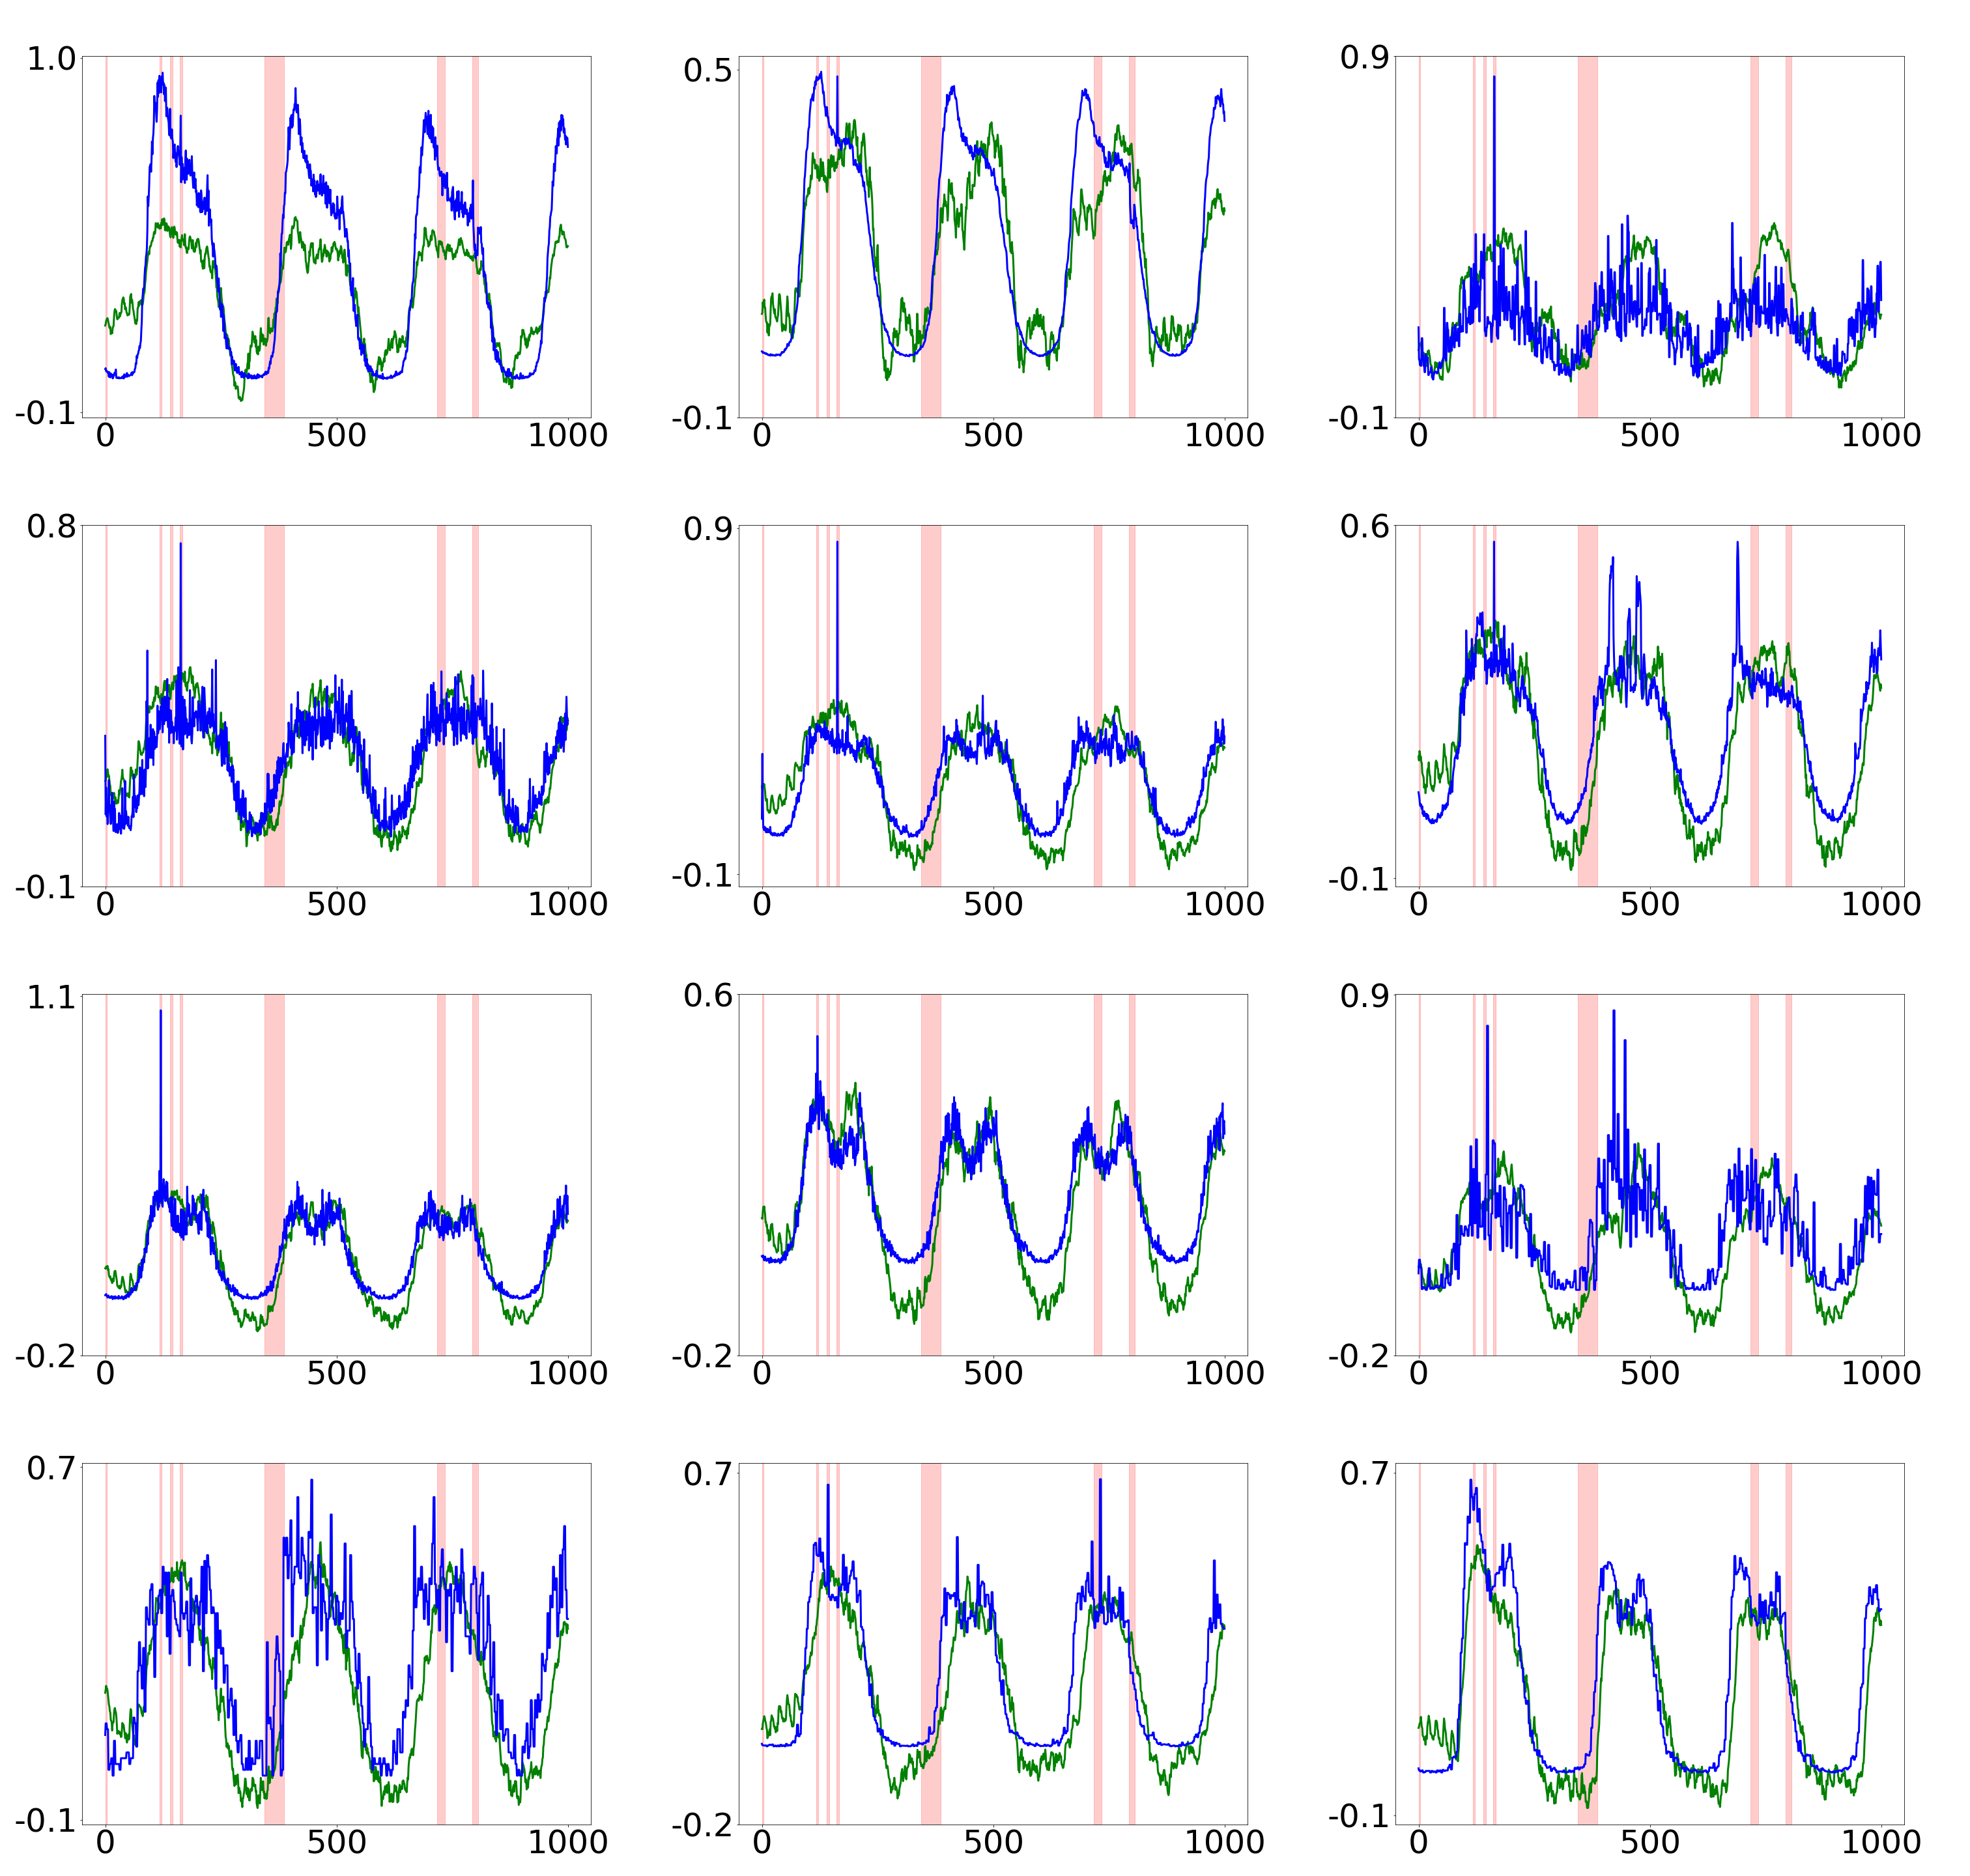

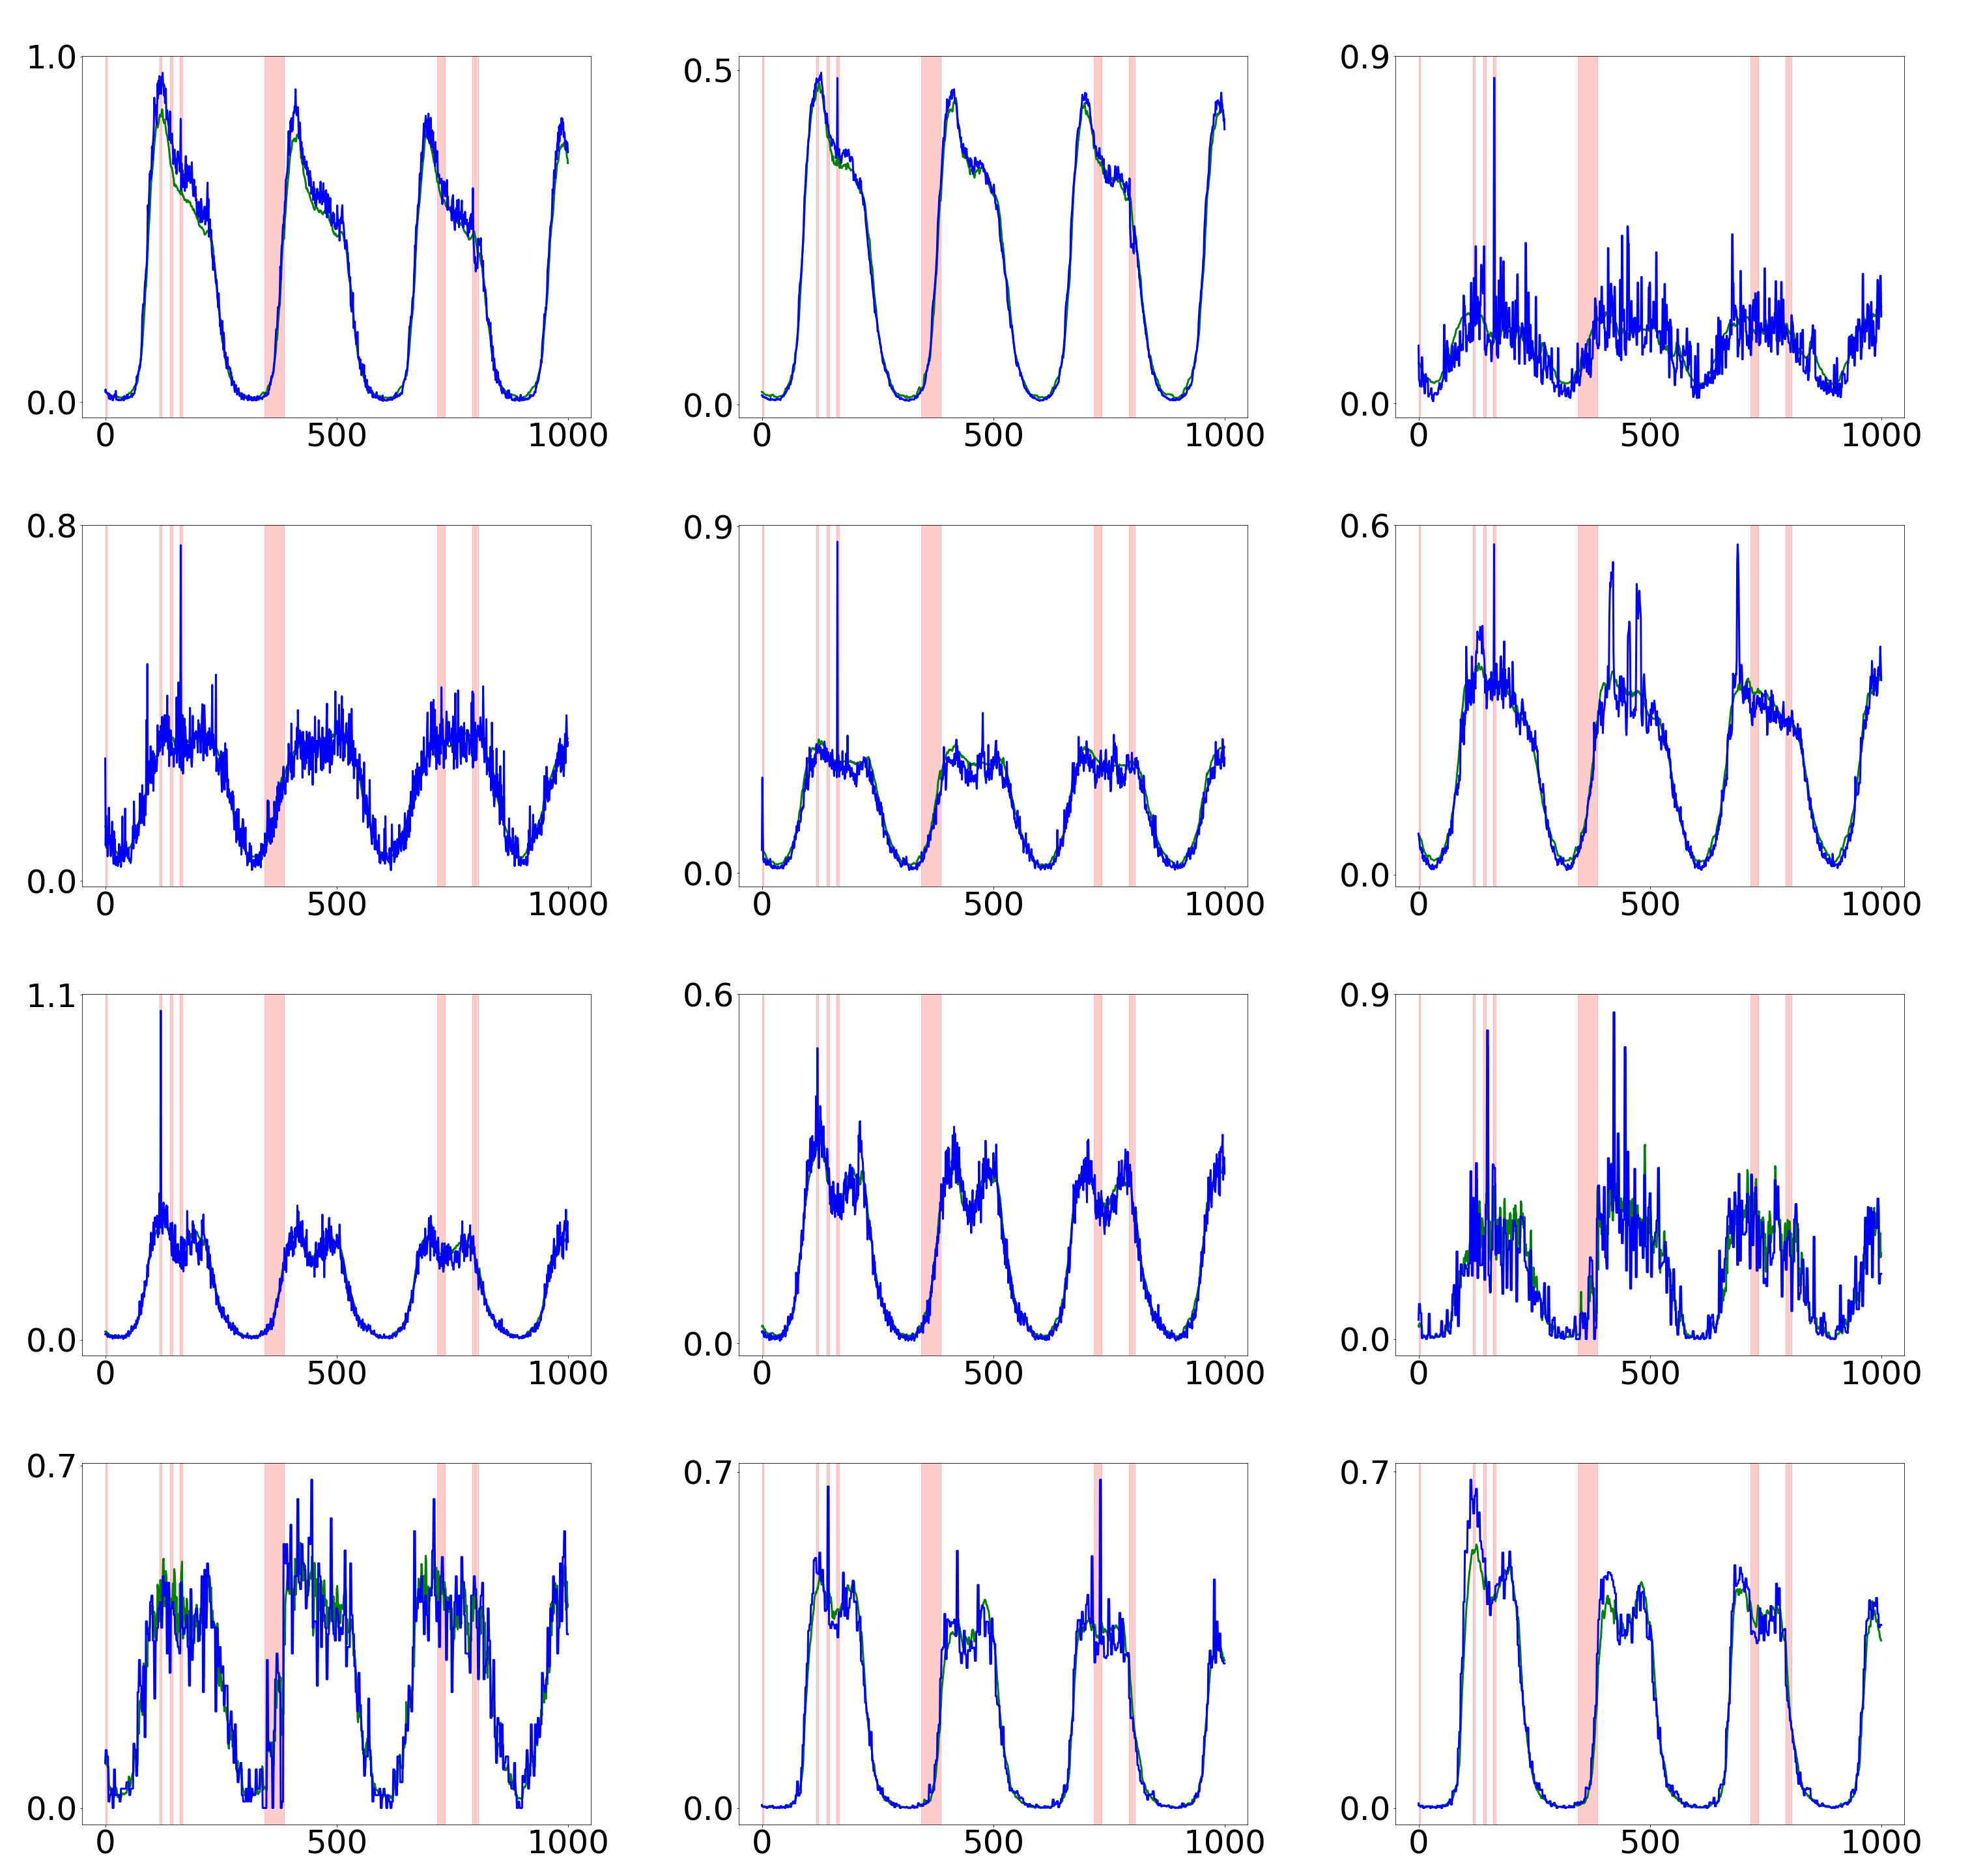

In [4]:
anomaly_columns = [0,1,2,3,4,5,6,7,8,9,10,11]

custom_start_index = 1000
custom_end_index = 2000
gru_figs = []
for column in anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gru_val[custom_start_index:custom_end_index, column],
        data_gru_val[custom_start_index:custom_end_index, column],
        labels_gru_single_val[custom_start_index:custom_end_index],
        "GRU",
        "TELCO",
        f"gru_anomaly_{column}.png",
        plot_legend=column == 29,
        title=column
    )
    gru_figs.append(
        f"gru_anomaly_{column}.png"
    )
    
 
display(generate_grid(gru_figs, cols=3, file_name="gru_anomaly_grid.png", dataset_name="telco"))


# Generate grid for GDN figures
gdn_figs = []
for column in anomaly_columns:
    
    generate_forecast_and_series_fig(
        output_gdn_val[custom_start_index:custom_end_index, column],
        data_gdn_val[custom_start_index:custom_end_index, column],
        labels_gdn_single_val[custom_start_index:custom_end_index],
        "GDN",
        "TELCO",
        f"gdn_anomaly_{column}.png"
    )
    gdn_figs.append(
        f"gdn_anomaly_{column}.png"
    )

display(generate_grid(gdn_figs, cols=3, file_name="gdn_anomaly_grid.png", dataset_name="telco"))

# Generate grid for GCN figures
gcn_figs = []
for column in anomaly_columns:
   
    generate_forecast_and_series_fig(
        output_gcn_val[custom_start_index:custom_end_index, column],
        data_gcn_val[custom_start_index:custom_end_index, column],
        labels_gcn_single_val[custom_start_index:custom_end_index],
        "GCN",
        "TELCO",
        f"gcn_anomaly_{column}.png" 
    )
    gcn_figs.append(
        f"gcn_anomaly_{column}.png"
    )

display(generate_grid(gcn_figs, cols=3, file_name="gcn_anomaly_grid.png", dataset_name="telco"))

mtad_gat_figs = []
mtad_gat_forecasts, mtad_gat_reconstruction = output_mtad_gat_val
for column in anomaly_columns:
    generate_forecast_and_series_fig(
        mtad_gat_forecasts[custom_start_index:custom_end_index, column],
        data_mtad_gat_val[custom_start_index:custom_end_index, column],
        labels_mtad_gat_single_val[custom_start_index:custom_end_index],
        "MTAD-GAT",
        "TELCO",
        f"mtad_gat_anomaly_{column}.png"
    )
    mtad_gat_figs.append(
        f"mtad_gat_anomaly_{column}.png"
    )

display(generate_grid(mtad_gat_figs, cols=3, file_name="mtad_gat_anomaly_grid.png", dataset_name="telco"))

In [5]:
# Print all outputs and data shapes
print("GDN outputs:", output_gdn_val.shape)
print("GDN data:", data_gdn_val.shape)
print("GDN labels:", labels_gdn_single_val.shape)

print("GCN outputs:", output_gcn_val.shape)
print("GCN data:", data_gcn_val.shape)
print("GCN labels:", labels_gcn_single_val.shape)

mtad_gat_forecasts, mtad_gat_reconstruction = output_mtad_gat_val
print("MTAD-GAT forecasts:", mtad_gat_forecasts.shape)
print("MTAD-GAT reconstruction:", mtad_gat_reconstruction.shape)
print("MTAD-GAT data:", data_mtad_gat_val.shape)
print("MTAD-GAT labels:", labels_mtad_gat_single_val.shape)

print("GRU outputs:", output_gru_val.shape)
print("GRU data:", data_gru_val.shape)
print("GRU labels:", labels_gru_single_val.shape)



GDN outputs: torch.Size([8484, 12])
GDN data: torch.Size([8485, 12])
GDN labels: torch.Size([8434])
GCN outputs: torch.Size([8434, 12])
GCN data: torch.Size([8434, 12])
GCN labels: torch.Size([8434])
MTAD-GAT forecasts: torch.Size([8434, 12])
MTAD-GAT reconstruction: torch.Size([8434, 12])
MTAD-GAT data: torch.Size([8434, 12])
MTAD-GAT labels: torch.Size([8434])
GRU outputs: torch.Size([8434, 12])
GRU data: torch.Size([8434, 12])
GRU labels: torch.Size([8434])


## General Predictions

In [4]:
def generate_timeline_plots(predictions_list: list[np.ndarray], names: list[str]):
    """
    Plot horizontal timeline bars showing normal/anomaly regions for multiple prediction sets.
    
    Args:
        predictions_list: List of 1D numpy arrays containing predictions (0=normal, 1=anomaly)
        names: List of names/labels for each prediction set
    """
    font_size = 20
    plt.style.use("ggplot")
    
    # Create figure with appropriate height
    fig, ax = plt.subplots(figsize=(20, max(8, len(predictions_list) * 0.8)))
    
    ax.set_facecolor("white")
    fig.set_facecolor("white")
    
    bar_height = 0.6  # Height of each bar
    
    for idx, (predictions, name) in enumerate(zip(predictions_list, names)):
        time_indices = np.arange(len(predictions))
        
        # Plot normal regions (green)
        normal_mask = predictions < 0.5
        ax.fill_between(time_indices, 
                       idx - bar_height/2, 
                       idx + bar_height/2, 
                       where=normal_mask,
                       color="#2ecc71",
                       alpha=0.6)
        
        # Plot anomaly regions (red)
        anomaly_mask = predictions >= 0.5
        ax.fill_between(time_indices, 
                       idx - bar_height/2, 
                       idx + bar_height/2, 
                       where=anomaly_mask,
                       color="#ff0000",
                       alpha=1.0)
    
    # Configure axis and labels
    ax.set_yticks(range(len(predictions_list)))
    ax.set_yticklabels(names, fontsize=font_size)
    
    # Remove top and right spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    
    ax.set_xlabel("Time Index", fontsize=font_size, fontweight="bold")
    
    # Customize grid
    ax.grid(True, axis="x", alpha=0.2, linestyle="--")
    ax.set_axisbelow(True)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#2ecc71", alpha=0.6, label="Normal"),
        Patch(facecolor="#ff0000", alpha=1.0, label="Anomaly"),
    ]
    ax.legend(handles=legend_elements, fontsize=font_size)
    
    ax.tick_params(axis="x", labelsize=font_size)
    plt.subplots_adjust(bottom=0.2)
    
    return fig

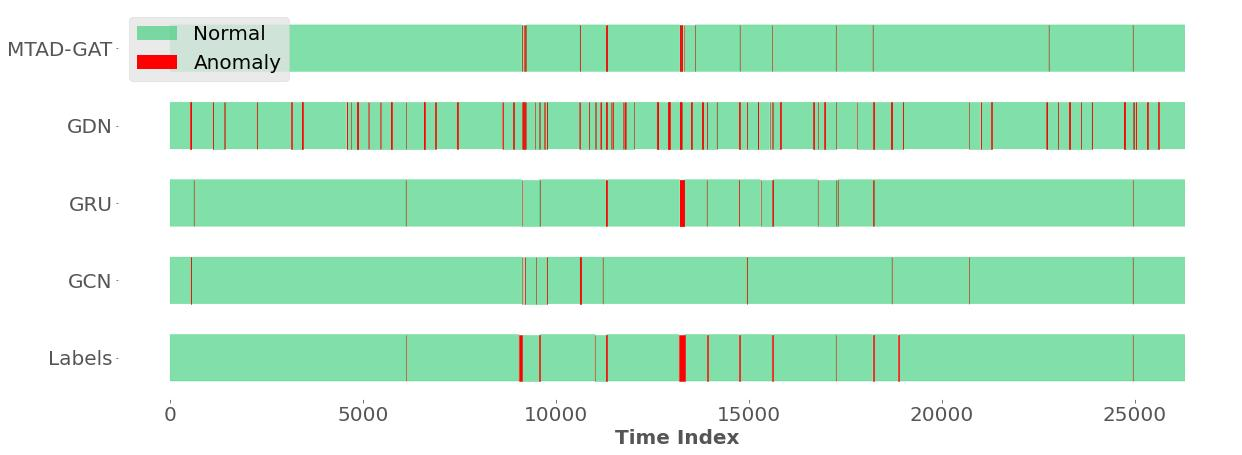

In [12]:
column = 0
fig = generate_timeline_plots(
    predictions_list=[labels_gcn_test[:, column].numpy(), predictions_gcn_test[:, column].numpy(), predictions_gru_test[:, column].numpy(), predictions_gdn_test[:, column].numpy(), predictions_mtad_gat_test[:, column].numpy()],
    names=["Labels", "GCN", "GRU", "GDN", "MTAD-GAT"]
)

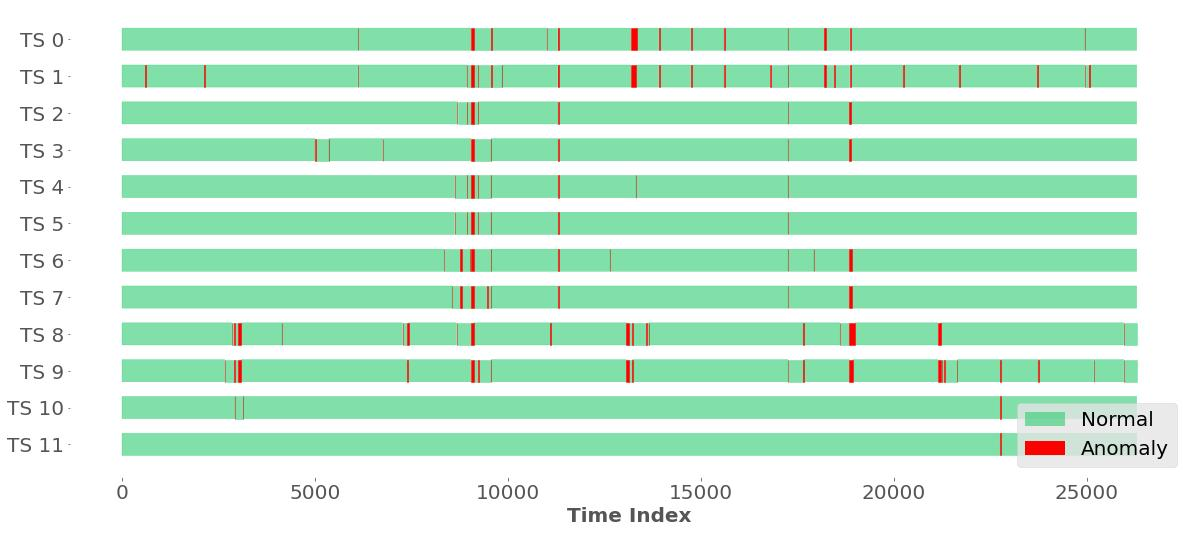

In [6]:
fig = generate_timeline_plots(
    predictions_list=[labels_gcn_test[:,col].numpy() for col in range(labels_gcn_test.shape[1]-1, -1, -1)],
    names=[f"TS {i}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)

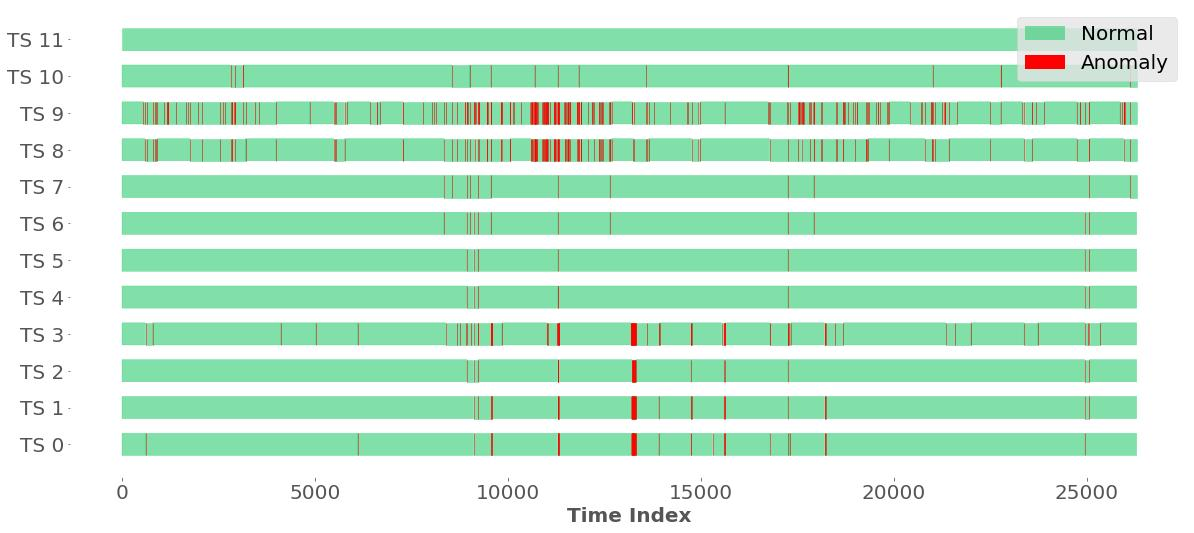

In [15]:
fig = generate_timeline_plots(
    predictions_list=[predictions_gru_test[:,col].numpy() for col in range(labels_gcn_test.shape[1]-1, -1, -1)],
    names=[f"TS {i}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)

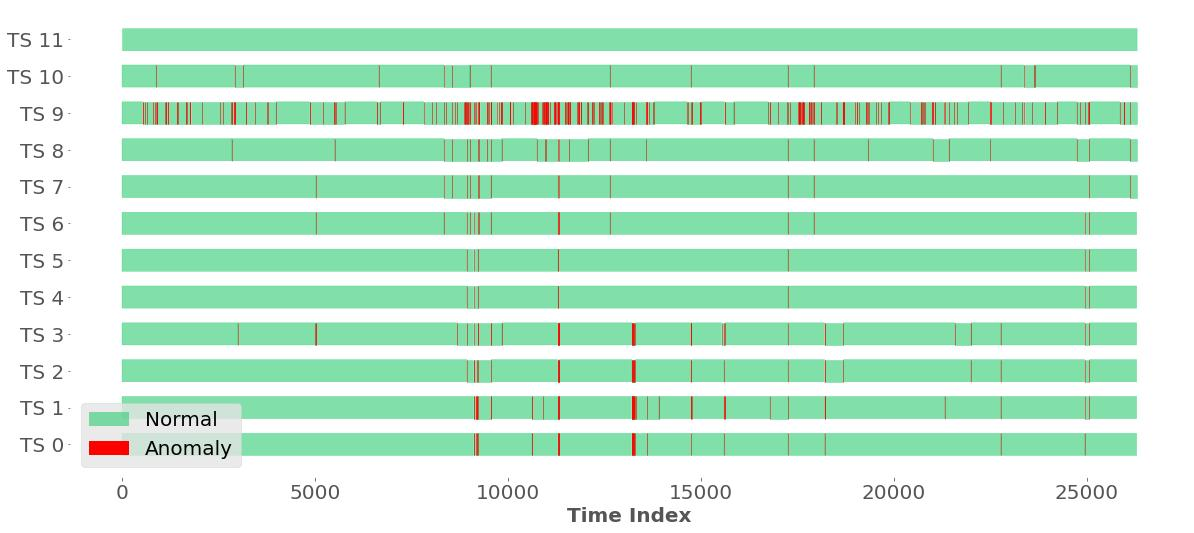

In [16]:
fig = generate_timeline_plots(
    predictions_list=[predictions_mtad_gat_test[:,col].numpy() for col in range(labels_gcn_test.shape[1]-1, -1, -1)],
    names=[f"TS {i}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)

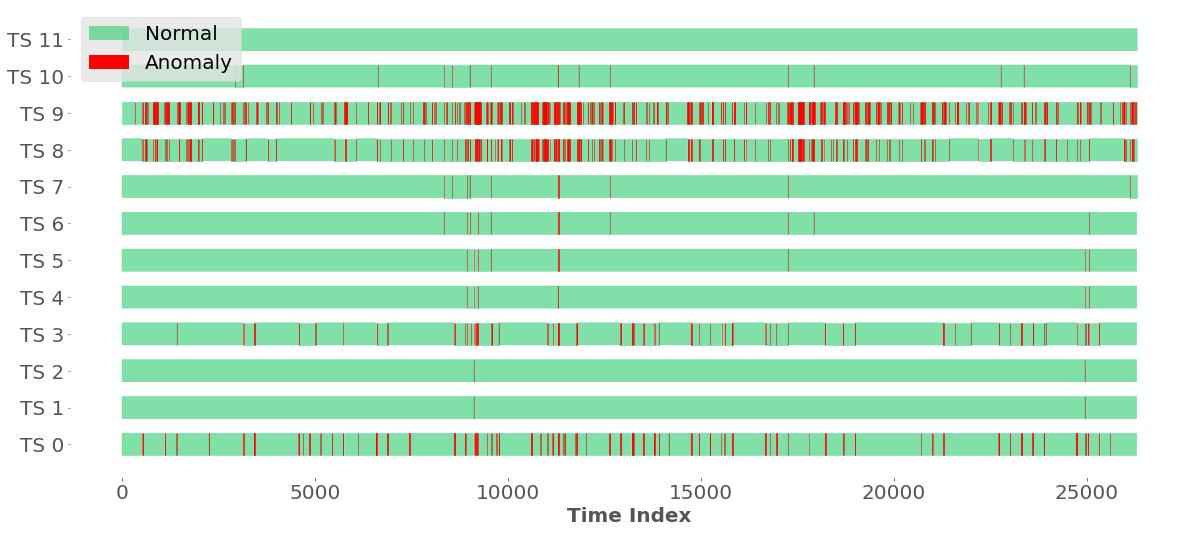

In [17]:
fig = generate_timeline_plots(
    predictions_list=[predictions_gdn_test[:,col].numpy() for col in range(labels_gcn_test.shape[1]-1, -1, -1)],
    names=[f"TS {i}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)

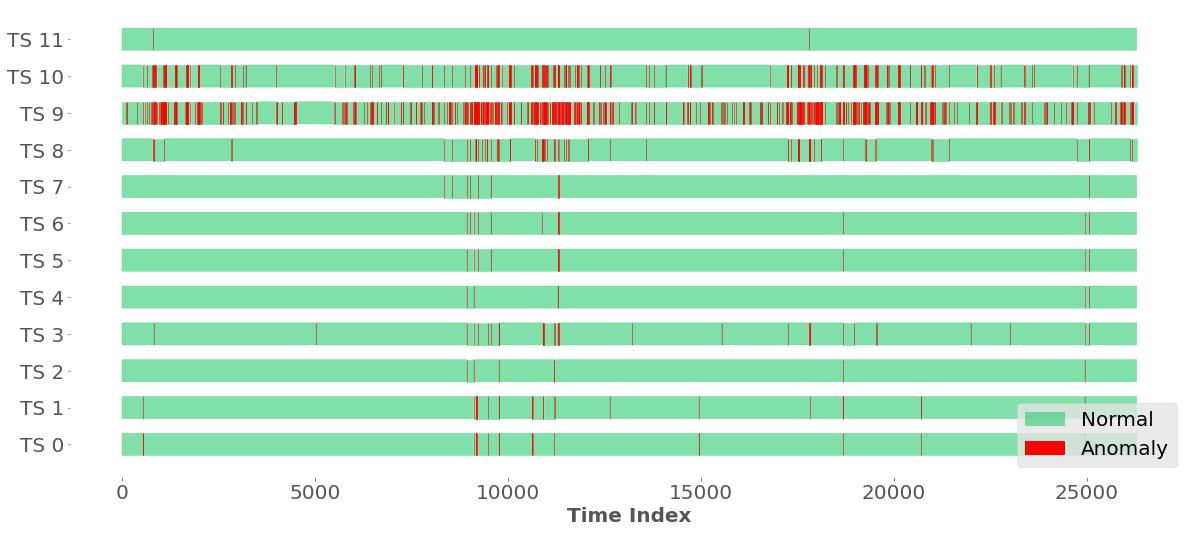

In [14]:
fig = generate_timeline_plots(
    predictions_list=[predictions_gcn_test[:,col].numpy() for col in range(labels_gcn_test.shape[1]-1, -1, -1)],
    names=[f"TS {i}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)

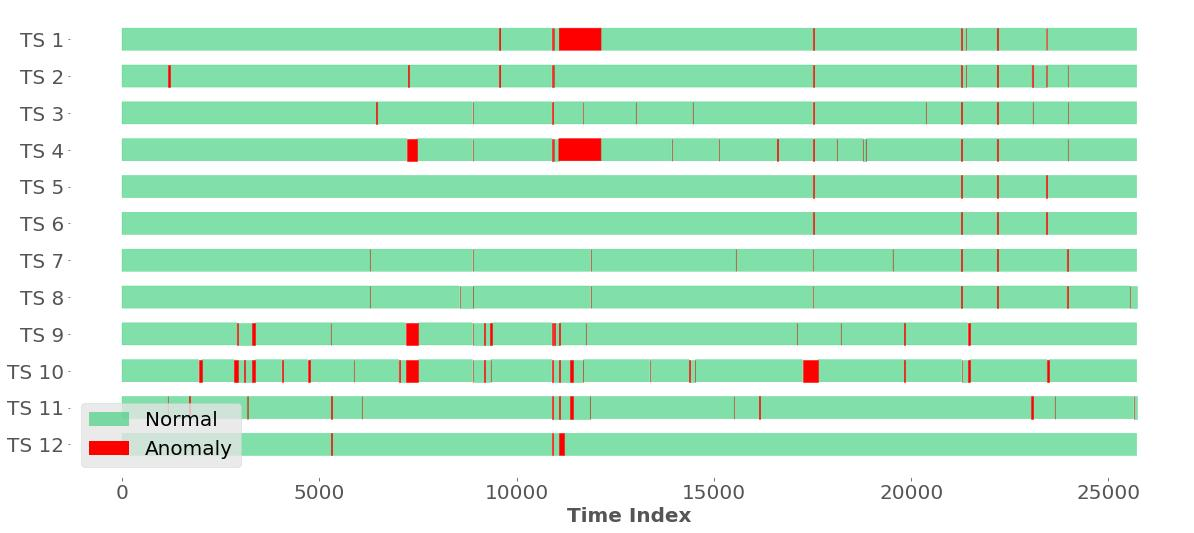

In [5]:
fig = generate_timeline_plots(
    predictions_list=[labels_gru_train[:,col].numpy() for col in range(labels_gru_train.shape[1]-1, -1, -1)],
    names=[f"TS {i+1}" for i in range(labels_gru_train.shape[1]-1, -1, -1)]
)
fig.savefig("anomalies_distribution/telco_labels_temporal_distribution_train.pdf", bbox_inches="tight", dpi=1000)

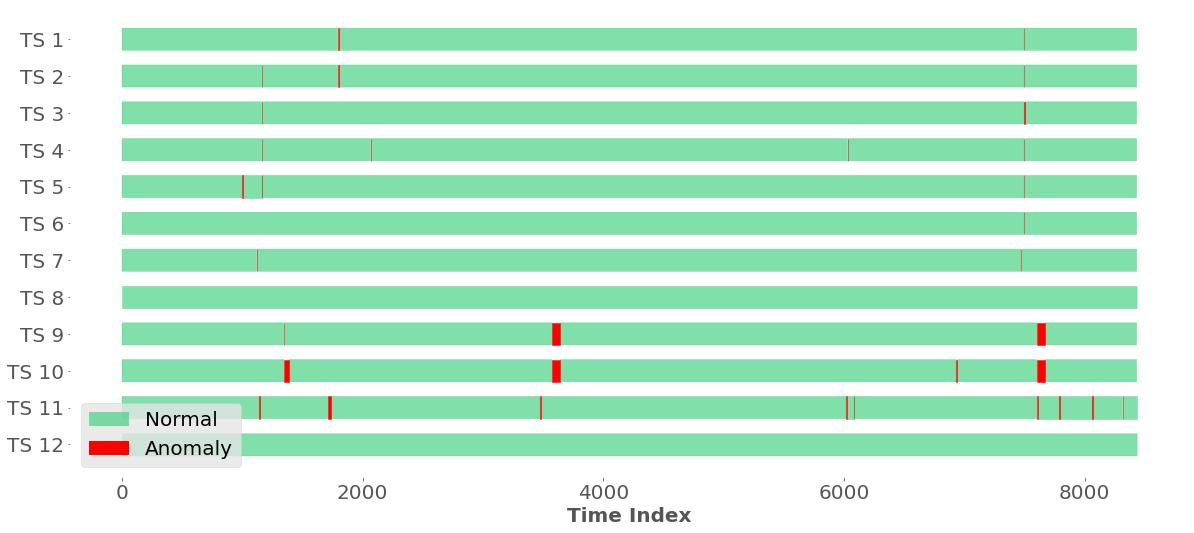

In [6]:
fig = generate_timeline_plots(
    predictions_list=[labels_gcn_val[:,col].numpy() for col in range(labels_gcn_val.shape[1]-1, -1, -1)],
    names=[f"TS {i+1}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)
fig.savefig("anomalies_distribution/telco_labels_temporal_distribution_val.pdf", bbox_inches="tight", dpi=1000)

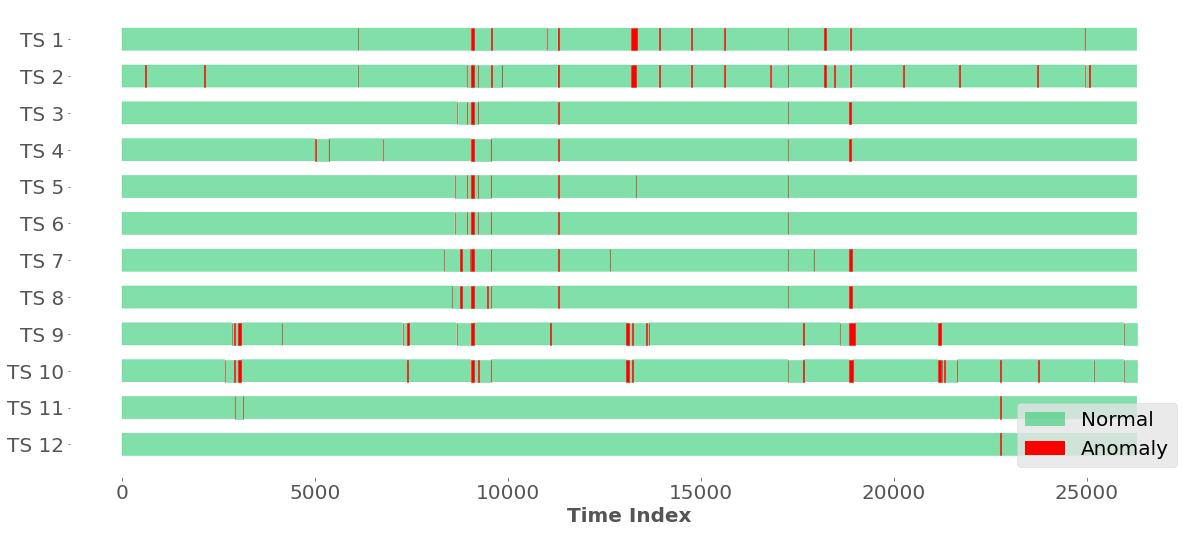

In [7]:
fig = generate_timeline_plots(
    predictions_list=[labels_gcn_test[:,col].numpy() for col in range(labels_gcn_test.shape[1]-1, -1, -1)],
    names=[f"TS {i+1}" for i in range(labels_gcn_test.shape[1]-1, -1, -1)]
)
fig.savefig("anomalies_distribution/telco_labels_temporal_distribution_test.pdf", bbox_inches="tight", dpi=1000)